In [1]:
import os
import pickle
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cuda


In [2]:

video_path = r"C:\Users\User\Desktop\deeplearning\fusion\video_features_256.pkl"
audio_path = r"C:\Users\User\Desktop\deeplearning\fusion\audio_feat.pkl"
text_path = r"C:\Users\User\Desktop\deeplearning\fusion\text_features_256(basic+earlystop).pkl"

# 2199개 샘플, 이미지 높이 224, 이미지 너비 224, RGB 3채널
with open(video_path, "rb") as f: 
    video_data = pickle.load(f)
X_video = video_data["features"]
X_video_labels = video_data["labels"] 



with open(audio_path, "rb") as f:
    audio_data = pickle.load(f)
X_audio = audio_data["audio_feat"]
X_audio_labels = audio_data["labels"]


text_data = torch.load(text_path,map_location=device)
X_text = text_data["features"]
X_text_labels = text_data["labels"]

# with open(text_path, "rb") as f:
#     text_data = pickle.load(f)
# X_text = text_data["features"]
# X_text_labels = text_data["labels"]

X_video_labels = torch.as_tensor(X_video_labels).long()
X_audio_labels = torch.as_tensor(X_audio_labels).long()
X_text_labels = torch.as_tensor(X_text_labels).long()


print(f"X_video      : {X_video.shape} ") # (224, 224, 3)
print(f"X_video_labels: (긍정 {X_video_labels.sum()} / 부정 {(X_video_labels==0).sum()})")

print(f"X_audio      : {X_audio.shape} ")
print(f"X_audio_labels: (긍정 {X_audio_labels.sum()} / 부정 {(X_audio_labels==0).sum()})")

print(f"X_text      : {X_text.shape} ")
print(f"X_text_labels: (긍정 {X_text_labels.sum()} / 부정 {(X_text_labels==0).sum()})")


X_video      : torch.Size([2199, 256]) 
X_video_labels: (긍정 1176 / 부정 1023)
X_audio      : torch.Size([2199, 256]) 
X_audio_labels: (긍정 1080 / 부정 1119)
X_text      : torch.Size([2199, 256]) 
X_text_labels: (긍정 1080 / 부정 1119)


그러나 라벨 분포가 video만 다르다

In [3]:
X_video_labels = torch.as_tensor(X_video_labels).cpu()
X_audio_labels = torch.as_tensor(X_audio_labels).cpu()
X_text_labels = torch.as_tensor(X_text_labels).cpu()

print(torch.equal(X_audio_labels, X_text_labels))
print(torch.equal(X_video_labels, X_text_labels))
print(torch.equal(X_video_labels, X_audio_labels))

True
False
False


feature 차원 기준 concat은 가능하나 label 기준 video 라벨이 달라 확인 필요
각자 차원수 맞춰왔으니 각 모달리티별 인코더 생략 가능

In [4]:
import torch.nn as nn

X_video = X_video.to(device)
X_audio = X_audio.to(device)
X_text = X_text.to(device)

# 세 모달리티 concat → MLP
fused = torch.cat([X_video, X_audio, X_text], dim=1)  # (N, 768)

input_dim = fused.shape[1]  # 768 + 768 + 768 = 2304


mlp = nn.Sequential(
    nn.Linear(input_dim, 256), 
    nn.ReLU(), 
    nn.Dropout(0.3),
    nn.Linear(256, 2)
)

y = torch.as_tensor(X_text_labels).long().to(device)  # (N,)

print(fused.shape)  # (N, 2304)
print(y.shape)
print(fused.device)

torch.Size([2199, 768])
torch.Size([2199])
cuda:0


In [5]:
# train / val / test split
N = fused.shape[0]
indices = torch.randperm(N,device=device)

train_size = int(0.7 * N)
val_size = int(0.15 * N)

train_idx = indices[:train_size]
val_idx = indices[train_size:train_size + val_size]
test_idx = indices[train_size + val_size:]

X_train, y_train = fused[train_idx], y[train_idx]
X_val, y_val = fused[val_idx], y[val_idx]
X_test, y_test = fused[test_idx], y[test_idx]

In [6]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score

In [7]:
#DataLoader
batch_size = 32

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val, y_val),
    batch_size=32,
    shuffle=False
)
test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=32,
    shuffle=False
)


In [8]:
MLP = nn.Sequential(
    nn.Linear(input_dim, 256), 
    nn.BatchNorm1d(256),
    nn.ReLU(), 
    nn.Dropout(0.5),
    nn.Linear(256, 3)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(MLP.parameters(), lr=1e-3)


In [9]:
def evaluate(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            total_loss += loss.item() 

            _, preds = torch.max(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    
    return avg_loss, acc, prec, rec, f1

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mlp = mlp.to(device)

optimizer = optim.Adam(mlp.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

train_losses = []
val_losses = []


epochs = 20

for epoch in range(epochs):
    mlp.train()
    total_loss = 0

for X_batch, y_batch in train_loader:
    X_batch = X_batch.to(device)
    y_batch = y_batch.to(device)

    optimizer.zero_grad()

    outputs = mlp(X_batch)
    loss = criterion(outputs, y_batch)

    loss.backward()
    optimizer.step()

In [11]:
print(next(mlp.parameters()).device)
print(fused.device)

cuda:0
cuda:0


In [12]:
mlp = mlp.to(fused.device)
optimizer = optim.Adam(mlp.parameters(), lr=1e-3)

print(next(mlp.parameters()).device)
print(fused.device)

cuda:0
cuda:0


In [13]:
history = {
    "train_loss": [],
    "train_acc": [],
    "train_prec": [],
    "train_rec": [],
    "train_f1": [], 

    "val_loss": [],
    "val_acc": [],
    "val_prec": [],
    "val_rec": [],
    "val_f1": [],

    "test_loss": [],
    "test_acc": [],
    "test_prec": [],
    "test_rec": [],
    "test_f1": []
}

epochs = 20

# Early Stopping
best_val_loss = float("inf")
patience_counter = 0
patience = 4  
best_model_state = None
best_epoch = 0


for epoch in range(epochs):
    mlp.train()
    
    total_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()

        outputs = mlp(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)

    train_loss, train_acc, train_prec, train_rec, train_f1 = evaluate(mlp, train_loader)
    val_loss, val_acc, val_prec, val_rec, val_f1 = evaluate(mlp, val_loader)
    test_loss, test_acc, test_prec, test_rec, test_f1 = evaluate(mlp, test_loader)

    # print(f"Epoch {epoch+1}/{epochs} ")
    # print(f"Loss: {train_loss:.4f} ")
    # print(f"Val Acc: {val_acc:.4f} ")
    # print(f"Val Prec: {val_prec:.4f} ")
    # print(f"Val Rec: {val_rec:.4f} ")
    # print(f"Val F1: {val_f1:.4f}")

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_prec"].append(train_prec)
    history["train_rec"].append(train_rec)
    history["train_f1"].append(train_f1)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_prec"].append(val_prec)
    history["val_rec"].append(val_rec)
    history["val_f1"].append(val_f1)

    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)
    history["test_prec"].append(test_prec)
    history["test_rec"].append(test_rec)
    history["test_f1"].append(test_f1)

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = mlp.state_dict().copy()
        best_epoch = epoch
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f} - Val Prec: {val_prec:.4f} - Val Rec: {val_rec:.4f} - Val F1: {val_f1:.4f}")
# 가장 성능 좋은 모델 불러오기 (early stopping 기준)
mlp.load_state_dict(best_model_state)

train_loss, train_acc, train_prec, train_rec, train_f1 = evaluate(mlp, train_loader)
val_loss, val_acc, val_prec, val_rec, val_f1 = evaluate(mlp, val_loader)
test_loss, test_acc, test_prec, test_rec, test_f1 = evaluate(mlp, test_loader)

print("\n=====================결과=====================")
print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} ,Train Prec: {train_prec:.4f} ,Train Rec: {train_rec:.4f} ,Train F1: {train_f1:.4f}")
print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} ,Val Prec: {val_prec:.4f} ,Val Rec: {val_rec:.4f} ,Val F1: {val_f1:.4f}")
print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f} ,Test Prec: {test_prec:.4f} ,Test Rec: {test_rec:.4f} ,Test F1: {test_f1:.4f}")

Epoch 1/20 - Train Loss: 0.2541 - Val Loss: 0.2858 - Val Acc: 0.9119 - Val Prec: 0.9172 - Val Rec: 0.8867 - Val F1: 0.9017
Epoch 2/20 - Train Loss: 0.2468 - Val Loss: 0.2859 - Val Acc: 0.9088 - Val Prec: 0.9054 - Val Rec: 0.8933 - Val F1: 0.8993
Epoch 3/20 - Train Loss: 0.2288 - Val Loss: 0.2855 - Val Acc: 0.9119 - Val Prec: 0.9060 - Val Rec: 0.9000 - Val F1: 0.9030
Epoch 4/20 - Train Loss: 0.2481 - Val Loss: 0.2991 - Val Acc: 0.9119 - Val Prec: 0.9231 - Val Rec: 0.8800 - Val F1: 0.9010
Epoch 5/20 - Train Loss: 0.2326 - Val Loss: 0.2820 - Val Acc: 0.9088 - Val Prec: 0.9110 - Val Rec: 0.8867 - Val F1: 0.8986
Epoch 6/20 - Train Loss: 0.2511 - Val Loss: 0.2921 - Val Acc: 0.9119 - Val Prec: 0.9060 - Val Rec: 0.9000 - Val F1: 0.9030
Epoch 7/20 - Train Loss: 0.2258 - Val Loss: 0.2778 - Val Acc: 0.9119 - Val Prec: 0.9116 - Val Rec: 0.8933 - Val F1: 0.9024
Epoch 8/20 - Train Loss: 0.2277 - Val Loss: 0.2809 - Val Acc: 0.9088 - Val Prec: 0.9054 - Val Rec: 0.8933 - Val F1: 0.8993
Epoch 9/20 - Tra

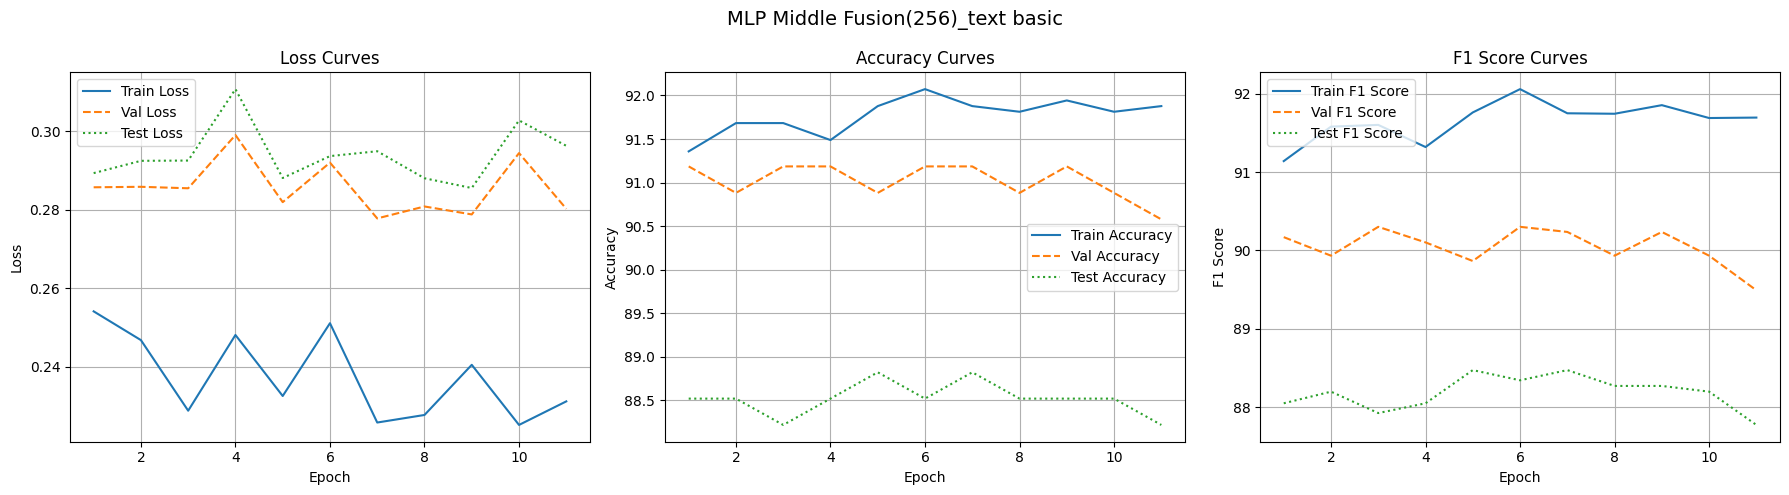

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# ============
# x축 epoch 설정
# ============
epochs_range = range(1, len(history["train_loss"]) + 1)

# ============
# 0~1 값을 0~ 100 퍼센트로 변환
# ============
def to_percentage(values):
    values = np.array(values)
    if values.max() <= 1.5:
        return values * 100
    return values

train_acc = to_percentage(history["train_acc"])
val_acc = to_percentage(history["val_acc"])
test_acc = to_percentage(history["test_acc"])

train_f1 = to_percentage(history["train_f1"])
val_f1 = to_percentage(history["val_f1"])
test_f1 = to_percentage(history["test_f1"])

plt.figure(figsize=(18, 5))
plt.suptitle("MLP Middle Fusion(256)_text basic", fontsize=14)


# ============
# Loss 그래프 그리기
# ============

plt.subplot(1, 3, 1)

plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], linestyle="--", label="Val Loss")
plt.plot(epochs_range, history["test_loss"], linestyle=":", label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()
plt.grid(True)


# ============
# Accuracy 그래프 그리기
# ============
plt.subplot(1, 3, 2)

plt.plot(epochs_range, train_acc, label="Train Accuracy")
plt.plot(epochs_range, val_acc, linestyle="--", label="Val Accuracy")
plt.plot(epochs_range, test_acc, linestyle=":", label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()
plt.grid(True)

# ============
# F1 Score 그래프 그리기
# ============

plt.subplot(1, 3, 3)

plt.plot(epochs_range, train_f1, label="Train F1 Score")
plt.plot(epochs_range, val_f1, linestyle="--", label="Val F1 Score")
plt.plot(epochs_range, test_f1, linestyle=":", label="Test F1 Score")

plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("F1 Score Curves")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()